In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2

define plot types

In [30]:
import sys
sys.path.append("../utils")
from plotting_utils import format_top_3, plot_metric_grouped_by, plot_bio_vs_batch_correction_markers, rename_reorder_methods, plot_embeddings, add_rfphate_phate_embeddings, define_methods_to_plot, plot_bio_vs_batch_correction_markers_legend_separate

In [4]:
# base_path = "/home/mila/m/myriam.lizotte/RF-MALI"
# mali_path = "/home/mila/m/myriam.lizotte/MALI"
# scratch_path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI"

batch = 4

results_path = "/NOBACKUP/lizottem/fosta/results"
exp_name = "simulated_batches"
results_name = "simulated_batches_new"
timestamp = "2026-05-04_17-31-59"
timestamp = "final_run"
save_name = f"simulated_batches/{timestamp}/{batch}" #dataset}".format(dataset = dataset_name)
save_path = f"{results_path}/{save_name}"


create a new summary df based on aggregating the dfs in the n_comp subfolders

In [91]:
import os

noises = [0.25, 0.5, 0.75]
dropouts = [0.25, 0.5, 0.75]
n_components_list = [2]
seeds = [39041, 56089, 79121]


all_results_df = pd.DataFrame()
for noise_std in noises:
    for dropout_prob in dropouts:
        for n_components in n_components_list:
            for seed in seeds:
                save_path_subfolder = f"{save_path}/noise_{noise_std}_dropout_{dropout_prob}/{n_components}_components/seed_{seed}"

                df = pd.read_csv(f"{save_path_subfolder}/simulated_batches_results.csv")

                all_results_df = pd.concat([all_results_df, df], ignore_index=True)
        
all_results_df    
all_results_df.to_csv(f"{save_path}/simulated_batches_new_results.csv", index=False)
            

In [78]:
# cols_batch = [col for col in results_df.columns if metric_type[col] == "Batch correction"]
# cols_bio = [col for col in results_df.columns if (metric_type[col] == "Bio conservation") or (metric_type[col] == "Bio Conservation (label-free)")]

# bio_cons_with_label_free = results_df.loc[cols_bio].mean(axis=1)
   

# Fake batches data

In [5]:
# load results

results_df = pd.read_csv(f"{save_path}/{results_name}_results.csv")
results_name = "simulated_batches_new"

metric_type = results_df.loc[results_df["method"] == "Metric Type"]
metric_type = metric_type.drop(columns=['method', "noise", "dropout", "seed", "n_components", "time", "memory", "folder"]).drop_duplicates()
results_df = results_df.loc[results_df["method"] != "Metric Type"]

# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['method', 'noise', 'dropout'])
results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')

noise_dropout_cols = ['noise', 'dropout']
results_df[noise_dropout_cols] = results_df[noise_dropout_cols].apply(pd.to_numeric, errors='coerce')


# results_df = results_df.drop(0, axis = 0) # remove one run from debugging
results_df.drop_duplicates(subset=['seed', 'n_components','method', 'noise', 'dropout'], keep='last', inplace=True)


# delete rows where n_components is NA
results_df = results_df.loc[~results_df["n_components"].isna()]
results_df = results_df.loc[~results_df["method"].isna()]


# remove n_components in the model column (it was just used to not overwrite adata, and it's already another column)
results_df["method"] = results_df["method"].str.replace(r'_\d+_components', '', regex=True)

reorder and rename the methods

In [7]:
right_fosta_name = "FoSTA_t2_balanced"
results_df = rename_reorder_methods(results_df, right_fosta_name=right_fosta_name)


# subset to the seeds where all methods ran
seeds = [39041, 56089, 79121]
results_df = results_df[results_df["seed"].isin(seeds)]

(!) Warning: 'FoSTA_t2_balanced' not found in 'method' column. please try with a different name.


In [9]:
supervised_methods = ['FoSTA',
                    'scANVI', 
                    'KEMAlin', 
                    'KEMArbf', 
                    'MALI', 
                    'Pamona']

for method in supervised_methods:
    results_df["method"] = results_df["method"].replace({method: f"{method} *"})


/tmp/ipykernel_2709398/1672141836.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  results_df["method"] = results_df["method"].replace({method: f"{method} *"})


# to find which rows are missing: 

In [93]:
# example columns
# df.columns = ['method', 'noise', 'dropout', 'seed']
df = results_df

# all expected values from the dataframe
methods = df['method'].unique()
noises = [0.25, 0.5, 0.75] 
dropouts = [0.25, 0.5, 0.75] 
seeds = df['seed'].unique()

# build all possible combinations
expected = pd.MultiIndex.from_product(
    [methods, noises, dropouts, seeds],
    names=['method', 'noise', 'dropout', 'seed']
)

# existing combinations
existing = pd.MultiIndex.from_frame(
    df[['method', 'noise', 'dropout', 'seed']]
)

# find missing ones
missing = expected.difference(existing)

# turn into dataframe
missing_df = missing.to_frame(index=False)

print(missing_df)

                 method  noise  dropout   seed
0        ICML FoSTA t=2   0.25     0.25  39041
1        ICML FoSTA t=2   0.25     0.50  39041
2     ICML FoSTA t=auto   0.25     0.25  39041
3     ICML FoSTA t=auto   0.25     0.50  39041
4     New FoSTA gap t=2   0.25     0.25  39041
5     New FoSTA gap t=2   0.25     0.50  39041
6  New FoSTA gap t=auto   0.25     0.25  39041
7  New FoSTA gap t=auto   0.25     0.50  39041


In [ ]:
# # just remove some methods
# methods_to_remove = ['Harmony', 'FoSTA_tauto_kerf', 'FoSTA_tauto_gap']
# methods_to_remove +=[method for method in results_df.method.unique() if "New FoSTA" in method]
# methods_to_remove +=[method for method in results_df.method.unique() if "Old FoSTA" in method]
# results_df = results_df[~results_df['method'].isin(methods_to_remove)]



# Remove isolated labels 
(because all the labels are shared) in this simulation

In [8]:
results_df.drop(columns=["Isolated labels"], inplace=True)

# Bio vs batch

In [112]:
save_path

'/NOBACKUP/lizottem/fosta/results/simulated_batches/final_run/4'

/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:434: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].mean()
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:435: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].std()


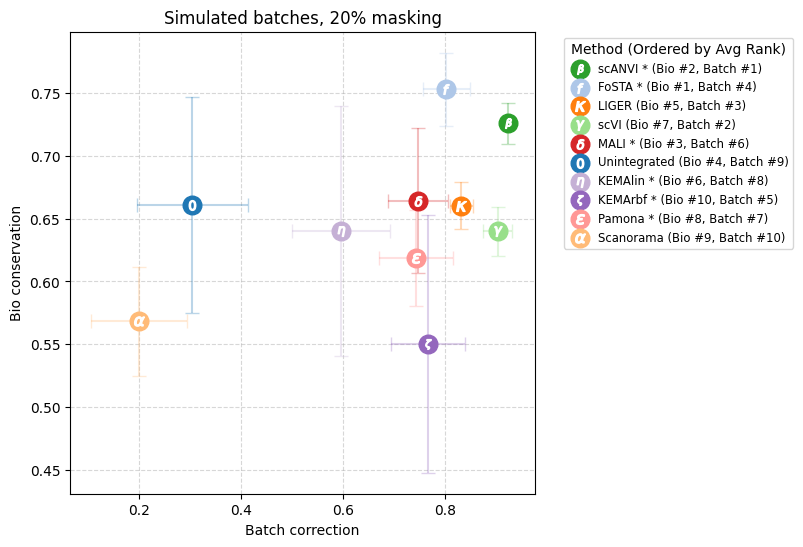

In [36]:
# methods_to_plot = define_methods_to_plot()
# methods_to_plot.remove("FoSTA_t2_et")
# methods_to_plot.remove("FoSTA_t2")
title = "Simulated batches, without isolated labels metric, 20% masking, 3 seeds, 3 noise levels, 3 dropout levels"
title = "Simulated batches, 20% masking"
plot_bio_vs_batch_correction_markers(results_df, title=title, save_path = save_path)

/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:824: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:825: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


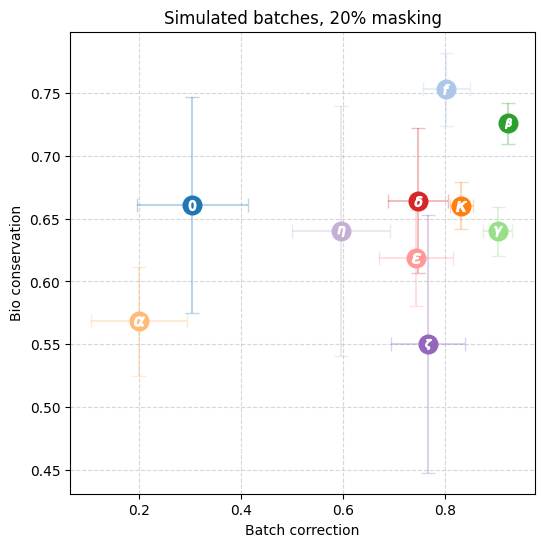

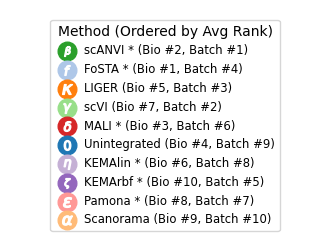

In [31]:
plot_bio_vs_batch_correction_markers_legend_separate(results_df, title=title, save_path = save_path)

/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:526: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction", "Total"]].mean()
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:527: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction", "Total"]].std()


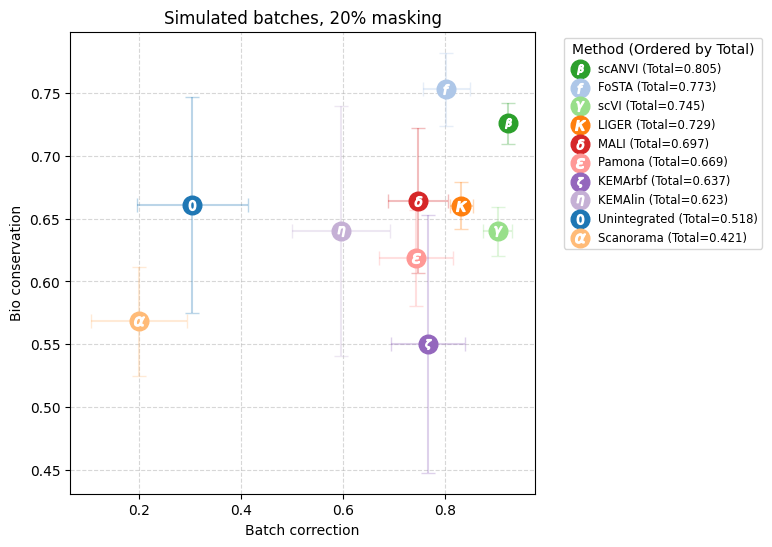

In [121]:
from plotting_utils import plot_bio_vs_batch_correction_markers_order_by_mean
plot_bio_vs_batch_correction_markers_order_by_mean(results_df, title=title)

In [105]:
print(save_path)

/NOBACKUP/lizottem/fosta/results/simulated_batches/final_run/4


# tables of bio and batch metrics

In [19]:
bio_metrics = []
batch_metrics = []
# metric_type = metric_type.drop("Isolated labels", axis=1)
for metric in metric_type.columns:
    if (metric_type[metric] == "Bio conservation").values[0]:
        bio_metrics.append(metric)
        
    elif (metric_type[metric] == "Batch correction").values[0]:
        batch_metrics.append(metric)


In [20]:
bio_avg = results_df.groupby(['method'])[bio_metrics].mean()
bio_std = results_df.groupby(['method'])[bio_metrics].std()

/tmp/ipykernel_2709398/2675270494.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bio_avg = results_df.groupby(['method'])[bio_metrics].mean()
/tmp/ipykernel_2709398/2675270494.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bio_std = results_df.groupby(['method'])[bio_metrics].std()


In [22]:
batch_avg = results_df.groupby(['method'])[batch_metrics].mean()
batch_std = results_df.groupby(['method'])[batch_metrics].std()

/tmp/ipykernel_2709398/2020476051.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_avg = results_df.groupby(['method'])[batch_metrics].mean()
/tmp/ipykernel_2709398/2020476051.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_std = results_df.groupby(['method'])[batch_metrics].std()


In [23]:
# change all columns to str
bio_avg = bio_avg.astype(float)
batch_avg = batch_avg.astype(float)

In [24]:
bio_avg

,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI
method,,,,,,
FoSTA *,0.613767,0.382320,0.817857,0.860120,0.856734,0.999784
LIGER,0.598940,0.389025,0.698874,0.635529,0.664318,0.998311
Scanorama,0.572012,0.420062,0.567140,0.409852,0.521092,0.991257
scANVI *,0.694738,0.462867,0.739641,0.616988,0.753099,1.000000
scVI,0.622050,0.383498,0.623827,0.492007,0.643845,0.999871
KEMAlin *,0.569633,0.393117,0.685872,0.653158,0.654518,0.978188
KEMArbf *,0.469410,0.296204,0.503498,0.400274,0.632303,0.960606
MALI *,0.527264,0.297789,0.730786,0.758943,0.707219,0.996178
Pamona *,0.585945,0.345894,0.628321,0.457048,0.640890,0.996302


In [25]:
format_top_3(bio_avg)

/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:217: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.614' '0.599' '0.572' '\\underline{0.695}' '\\textit{0.622}' '0.570'
 '0.469' '0.527' '0.586' '\\textbf{0.725}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[df.index, column] = df[column].apply(
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:217: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.382' '0.389' '\\textit{0.420}' '\\underline{0.463}' '0.383' '0.393'
 '0.296' '0.298' '0.346' '\\textbf{0.616}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[df.index, column] = df[column].apply(
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:217: FutureWarning: Settin

,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI
method,,,,,,
FoSTA *,0.614,0.382,\textbf{0.818},\textbf{0.860},\textbf{0.857},\textit{1.000}
LIGER,0.599,0.389,0.699,0.636,0.664,0.998
Scanorama,0.572,\textit{0.420},0.567,0.410,0.521,0.991
scANVI *,\underline{0.695},\underline{0.463},\underline{0.740},0.617,\underline{0.753},\textbf{1.000}
scVI,\textit{0.622},0.383,0.624,0.492,0.644,\underline{1.000}
KEMAlin *,0.570,0.393,0.686,\textit{0.653},0.655,0.978
KEMArbf *,0.469,0.296,0.503,0.400,0.632,0.961
MALI *,0.527,0.298,\textit{0.731},\underline{0.759},\textit{0.707},0.996
Pamona *,0.586,0.346,0.628,0.457,0.641,0.996


In [26]:

# add std
def add_std(summary_df, summary_df_std):
    summary_df_fmt = summary_df.copy()
    for col in summary_df.columns:
        summary_df_fmt[col] = (
            summary_df[col].astype(str)
            + r" {\small $\pm$ "
            + summary_df_std[col].round(3).astype(str)
            + "}"
        )
    return summary_df_fmt

bio = add_std(format_top_3(bio_avg), bio_std)
batch = add_std(format_top_3(batch_avg), batch_std)

/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:217: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.614' '0.599' '0.572' '\\underline{0.695}' '\\textit{0.622}' '0.570'
 '0.469' '0.527' '0.586' '\\textbf{0.725}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[df.index, column] = df[column].apply(
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:217: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.382' '0.389' '\\textit{0.420}' '\\underline{0.463}' '0.383' '0.393'
 '0.296' '0.298' '0.346' '\\textbf{0.616}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[df.index, column] = df[column].apply(
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:217: FutureWarning: Settin

In [27]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(batch.to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{llllll}
\toprule
 & BRAS & iLISI & KBET & Graph connectivity & PCR comparison \\
method &  &  &  &  &  \\
\midrule
FoSTA * & 0.447 {\small $\pm$ 0.087} & 0.917 {\small $\pm$ 0.031} & 0.747 {\small $\pm$ 0.145} & \textit{0.905} {\small $\pm$ 0.039} & \textit{0.999} {\small $\pm$ 0.001} \\
LIGER & 0.528 {\small $\pm$ 0.054} & \underline{0.953} {\small $\pm$ 0.009} & \textit{0.846} {\small $\pm$ 0.098} & 0.837 {\small $\pm$ 0.032} & \textbf{1.000} {\small $\pm$ 0.0} \\
Scanorama & 0.182 {\small $\pm$ 0.104} & 0.010 {\small $\pm$ 0.03} & 0.168 {\small $\pm$ 0.16} & 0.538 {\small $\pm$ 0.157} & 0.099 {\small $\pm$ 0.154} \\
scANVI * & \textbf{0.712} {\small $\pm$ 0.044} & \textbf{0.954} {\small $\pm$ 0.008} & \textbf{0.972} {\small $\pm$ 0.023} & \textbf{0.995} {\small $\pm$ 0.006} & 0.992 {\small $\pm$ 0.017} \\
scVI & \underline{0.697} {\small $\pm$ 0.05} & \textit{0.952} {\small $\pm$ 0.006} & \underline{0.919} {\small $\pm$ 0.093} & \underline{0.962} {\small $\pm$ 0.036}

In [28]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(bio.to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{lllllll}
\toprule
 & Leiden NMI & Leiden ARI & KMeans NMI & KMeans ARI & Silhouette label & cLISI \\
method &  &  &  &  &  &  \\
\midrule
FoSTA * & 0.614 {\small $\pm$ 0.033} & 0.382 {\small $\pm$ 0.044} & \textbf{0.818} {\small $\pm$ 0.046} & \textbf{0.860} {\small $\pm$ 0.051} & \textbf{0.857} {\small $\pm$ 0.031} & \textit{1.000} {\small $\pm$ 0.0} \\
LIGER & 0.599 {\small $\pm$ 0.024} & 0.389 {\small $\pm$ 0.038} & 0.699 {\small $\pm$ 0.037} & 0.636 {\small $\pm$ 0.059} & 0.664 {\small $\pm$ 0.021} & 0.998 {\small $\pm$ 0.001} \\
Scanorama & 0.572 {\small $\pm$ 0.063} & \textit{0.420} {\small $\pm$ 0.051} & 0.567 {\small $\pm$ 0.06} & 0.410 {\small $\pm$ 0.044} & 0.521 {\small $\pm$ 0.074} & 0.991 {\small $\pm$ 0.007} \\
scANVI * & \underline{0.695} {\small $\pm$ 0.032} & \underline{0.463} {\small $\pm$ 0.052} & \underline{0.740} {\small $\pm$ 0.028} & 0.617 {\small $\pm$ 0.046} & \underline{0.753} {\small $\pm$ 0.027} & \textbf{1.000} {\small $\pm$ 0.0} \\
scVI & \

In [29]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(format_top_3(bio_avg).to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{lllllll}
\toprule
 & Leiden NMI & Leiden ARI & KMeans NMI & KMeans ARI & Silhouette label & cLISI \\
method &  &  &  &  &  &  \\
\midrule
FoSTA * & 0.614 & 0.382 & \textbf{0.818} & \textbf{0.860} & \textbf{0.857} & \textit{1.000} \\
LIGER & 0.599 & 0.389 & 0.699 & 0.636 & 0.664 & 0.998 \\
Scanorama & 0.572 & \textit{0.420} & 0.567 & 0.410 & 0.521 & 0.991 \\
scANVI * & \underline{0.695} & \underline{0.463} & \underline{0.740} & 0.617 & \underline{0.753} & \textbf{1.000} \\
scVI & \textit{0.622} & 0.383 & 0.624 & 0.492 & 0.644 & \underline{1.000} \\
KEMAlin * & 0.570 & 0.393 & 0.686 & \textit{0.653} & 0.655 & 0.978 \\
KEMArbf * & 0.469 & 0.296 & 0.503 & 0.400 & 0.632 & 0.961 \\
MALI * & 0.527 & 0.298 & \textit{0.731} & \underline{0.759} & \textit{0.707} & 0.996 \\
Pamona * & 0.586 & 0.346 & 0.628 & 0.457 & 0.641 & 0.996 \\
Unintegrated & \textbf{0.725} & \textbf{0.616} & 0.622 & 0.468 & 0.604 & 0.995 \\
\bottomrule
\end{tabular}



# box plot

In [11]:
def boxplot(results_df, col="Total", savedir = None):
    
    fig, ax = plt.subplots()
    
    order_desc = results_df.groupby("method")[col].mean().sort_values(ascending=False).index.tolist()
    
    sns.barplot(data=results_df, x="method", y=col, palette="tab20", ax=ax, order = order_desc)
    plt.title(f"{col} score by method")

    # ax.set_title(f"{col}")
    ax.tick_params(axis="x", rotation=90)
    
    plt.tight_layout()

    if savedir is not None:
        plt.savefig(f"{savedir}/{col}.pdf", format='pdf')
        plt.savefig(f"{savedir}/{col}.png", format='png')

/tmp/ipykernel_3095895/1304805706.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order_desc = results_df.groupby("method")[col].mean().sort_values(ascending=False).index.tolist()
/tmp/ipykernel_3095895/1304805706.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="method", y=col, palette="tab20", ax=ax, order = order_desc)


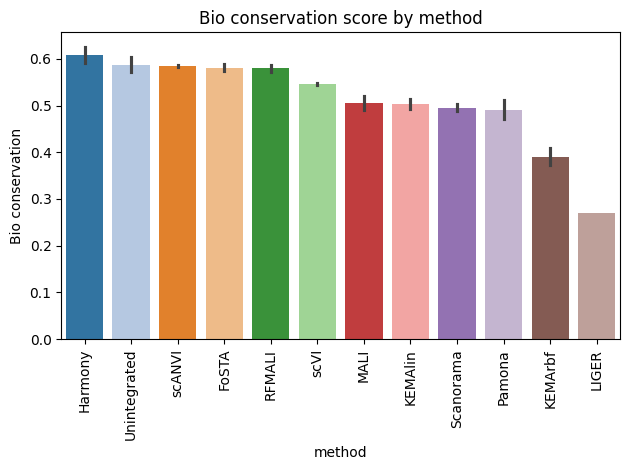

In [38]:
boxplot(results_df, col="Bio conservation", savedir = save_path)

# Bar plots

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:239: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


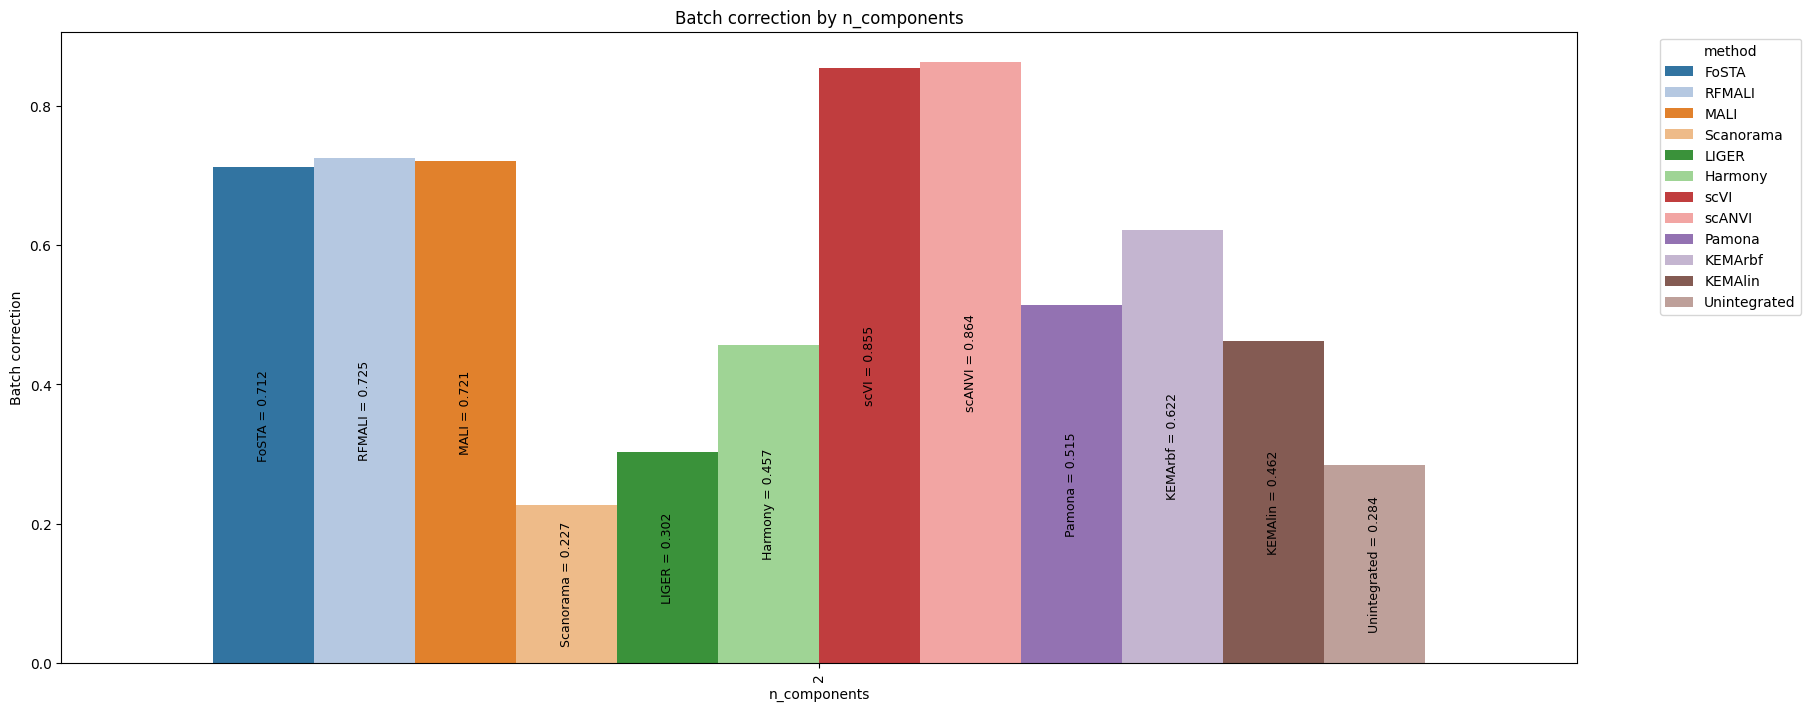

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:239: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


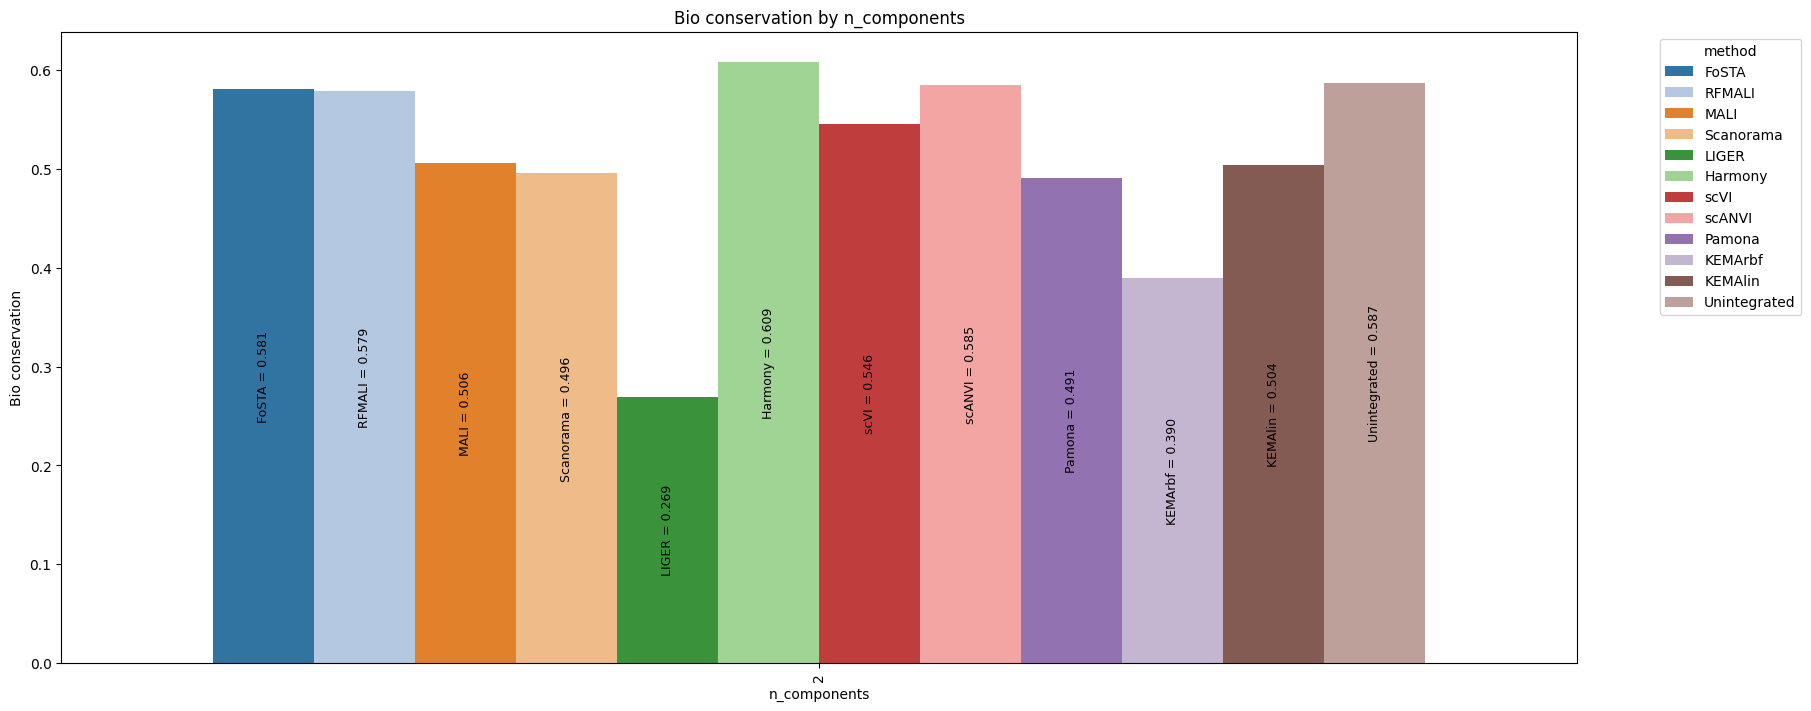

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:239: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


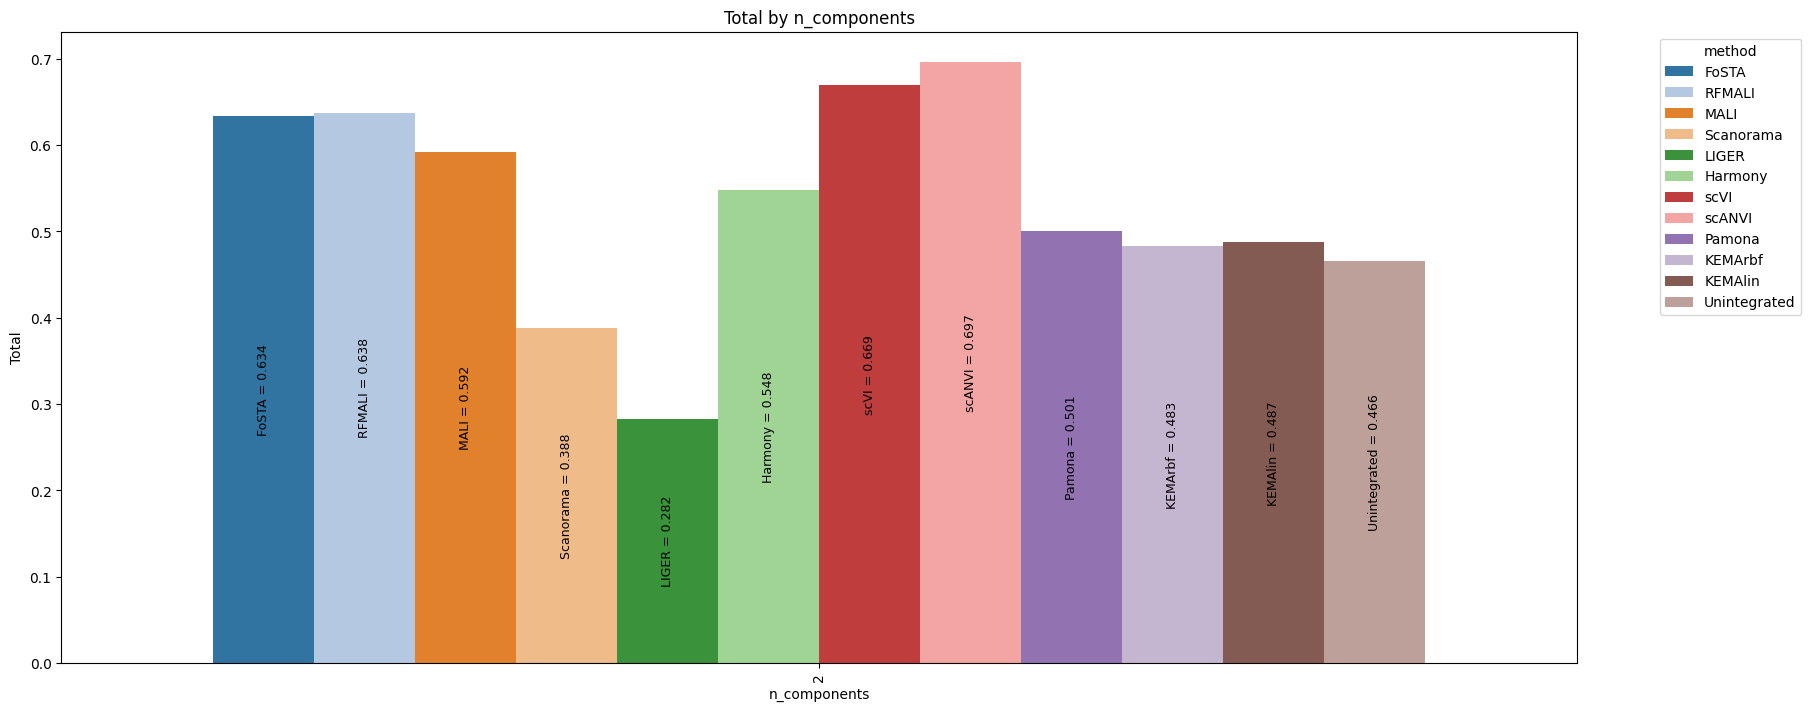

In [39]:
plot_metric_grouped_by(results_df, groupby_cols=["n_components", "method"])

subset to 2 components for visualization

/tmp/ipykernel_3118097/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


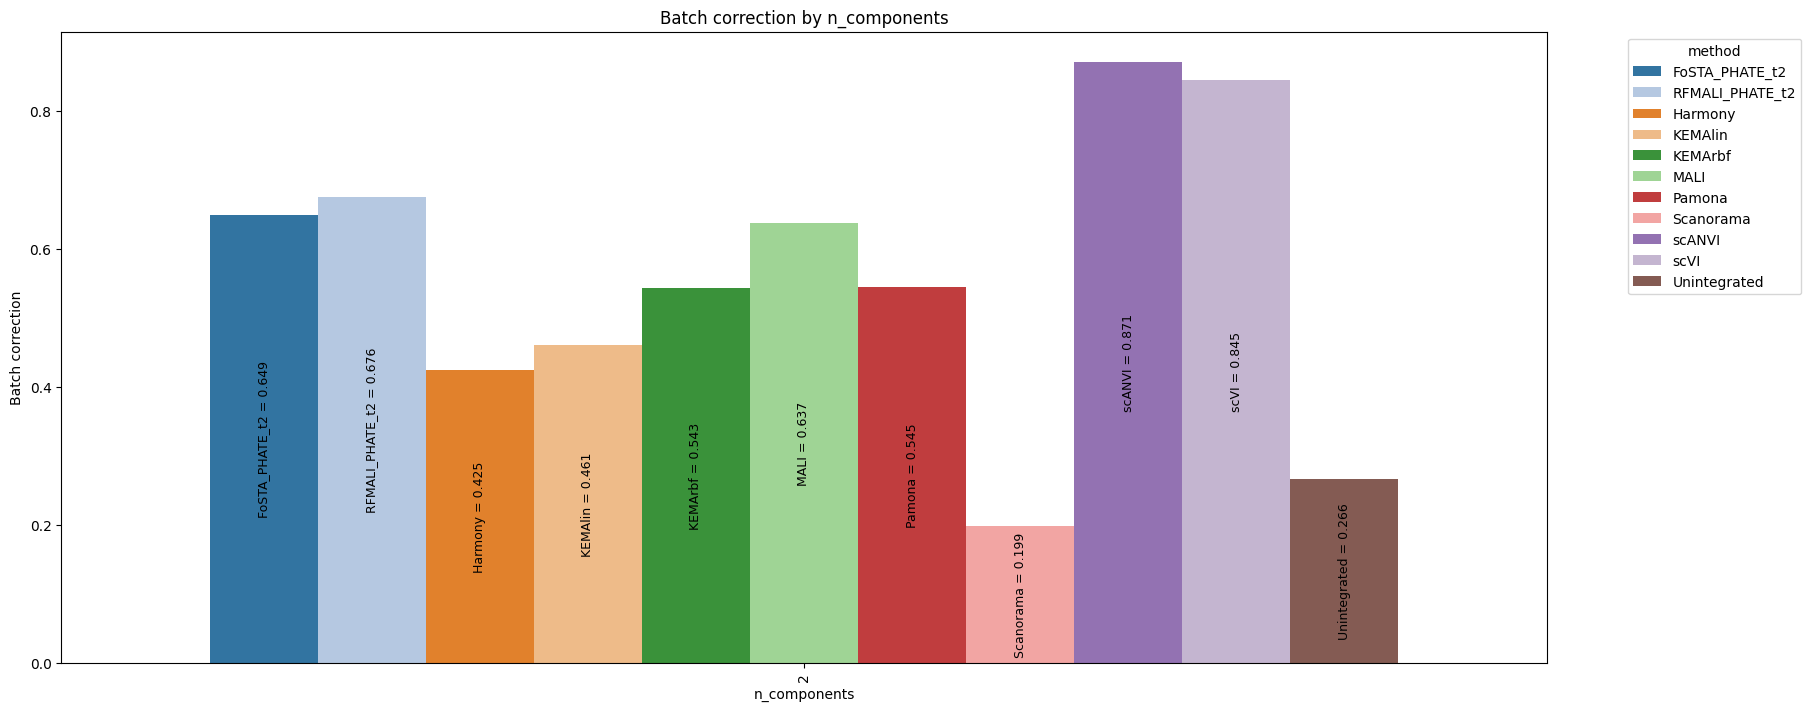

/tmp/ipykernel_3118097/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


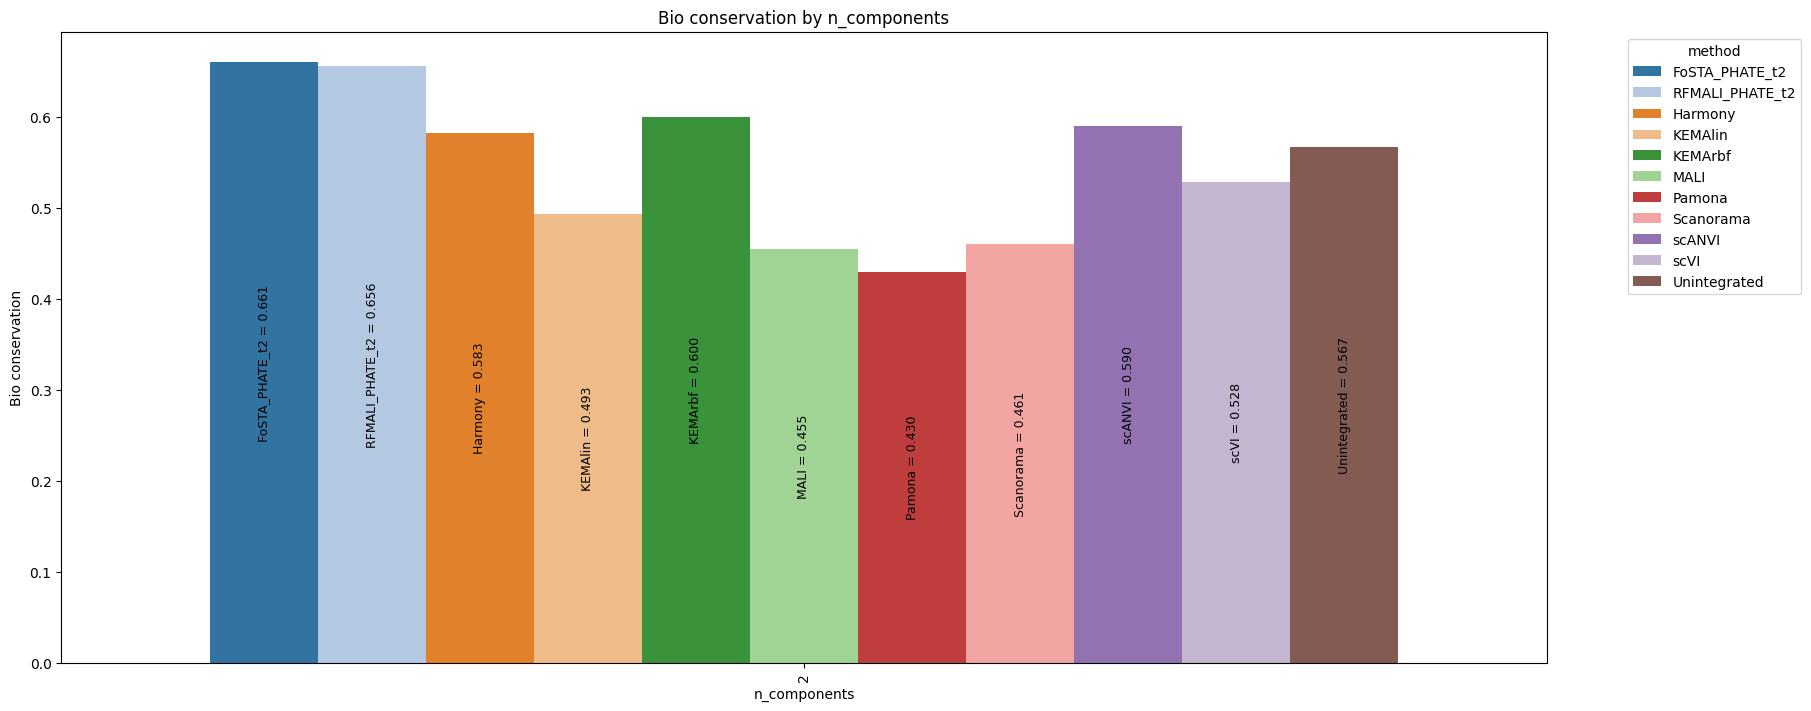

/tmp/ipykernel_3118097/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


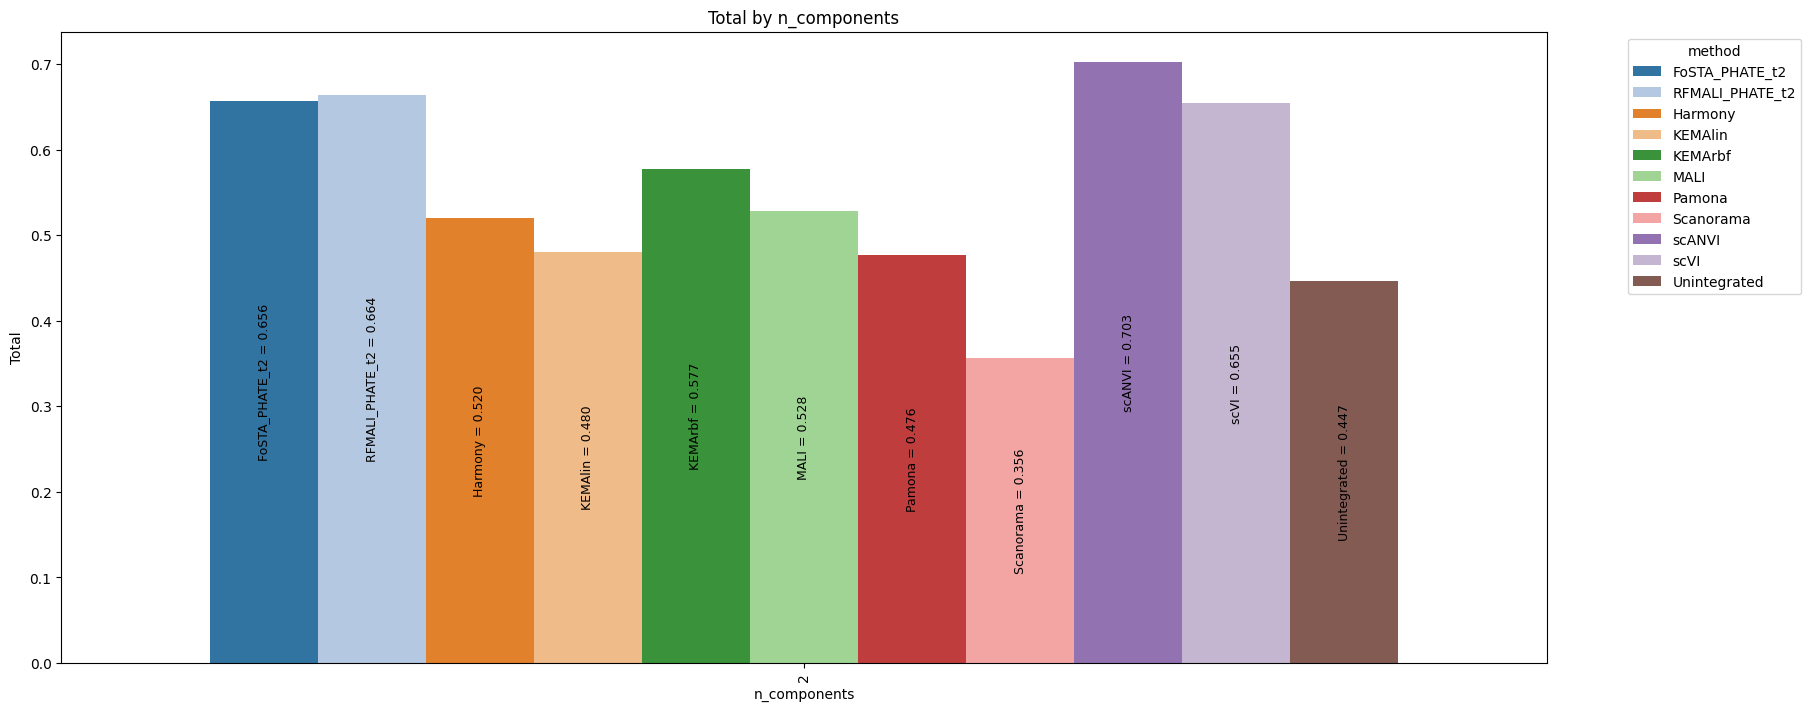

In [57]:
plot_metric_grouped_by(results_df, groupby_cols=["n_components","method"], n_components=2)

effect of noise when fixing dropout at 0.1:

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


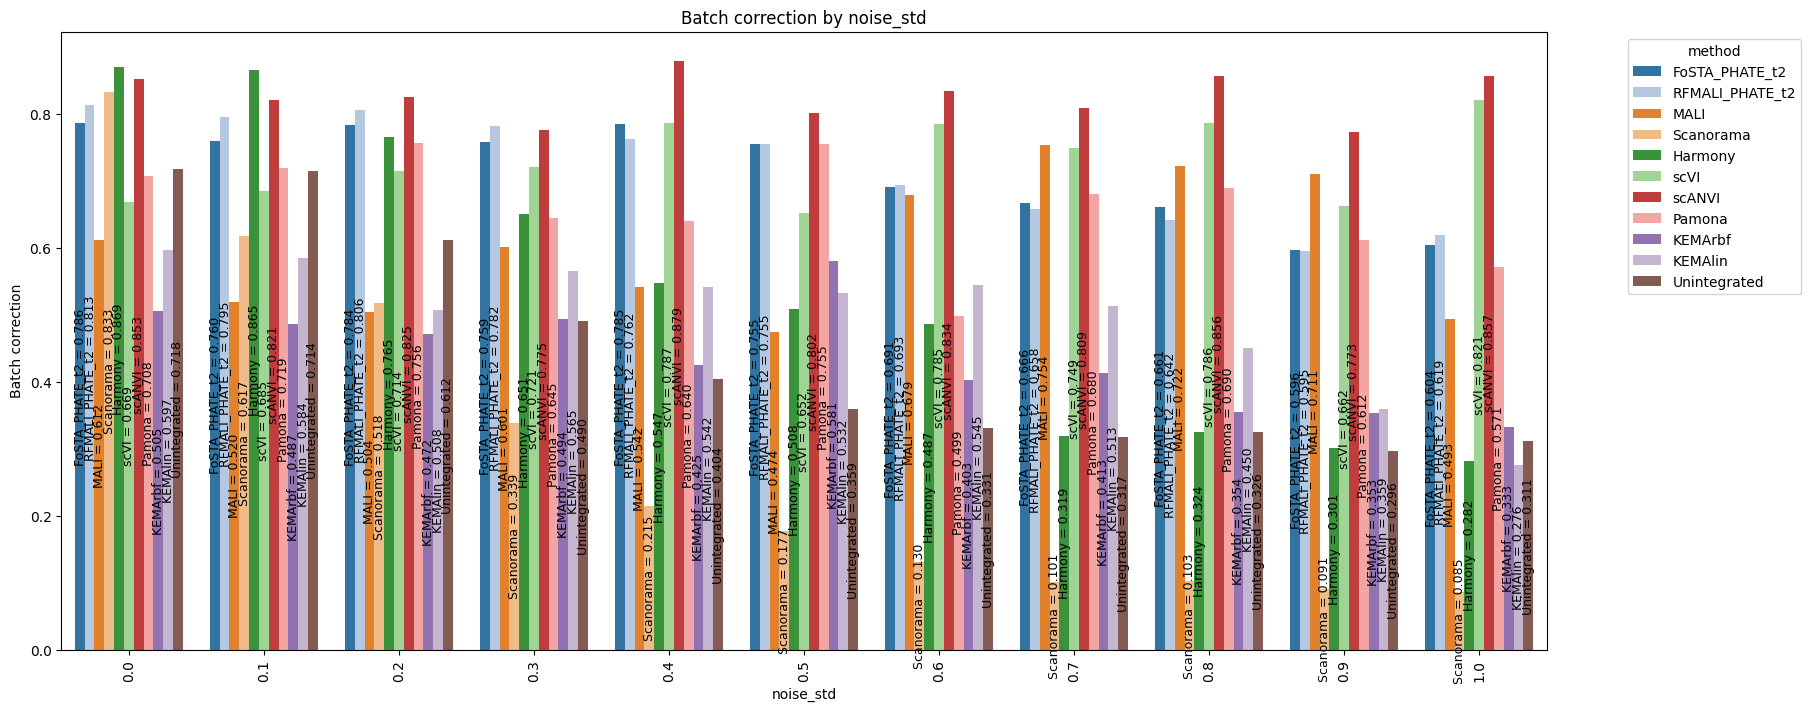

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


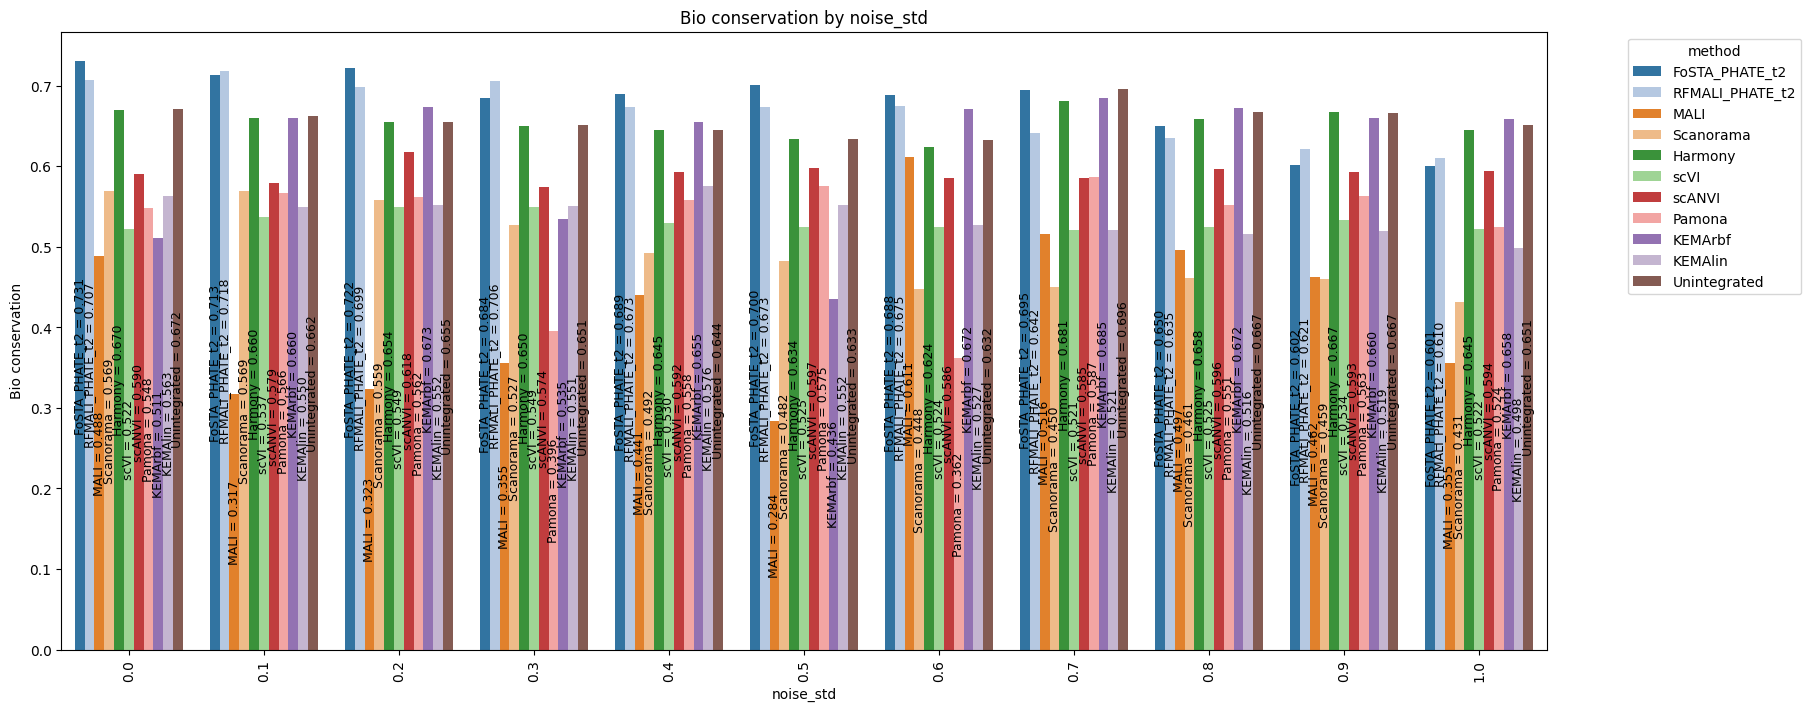

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


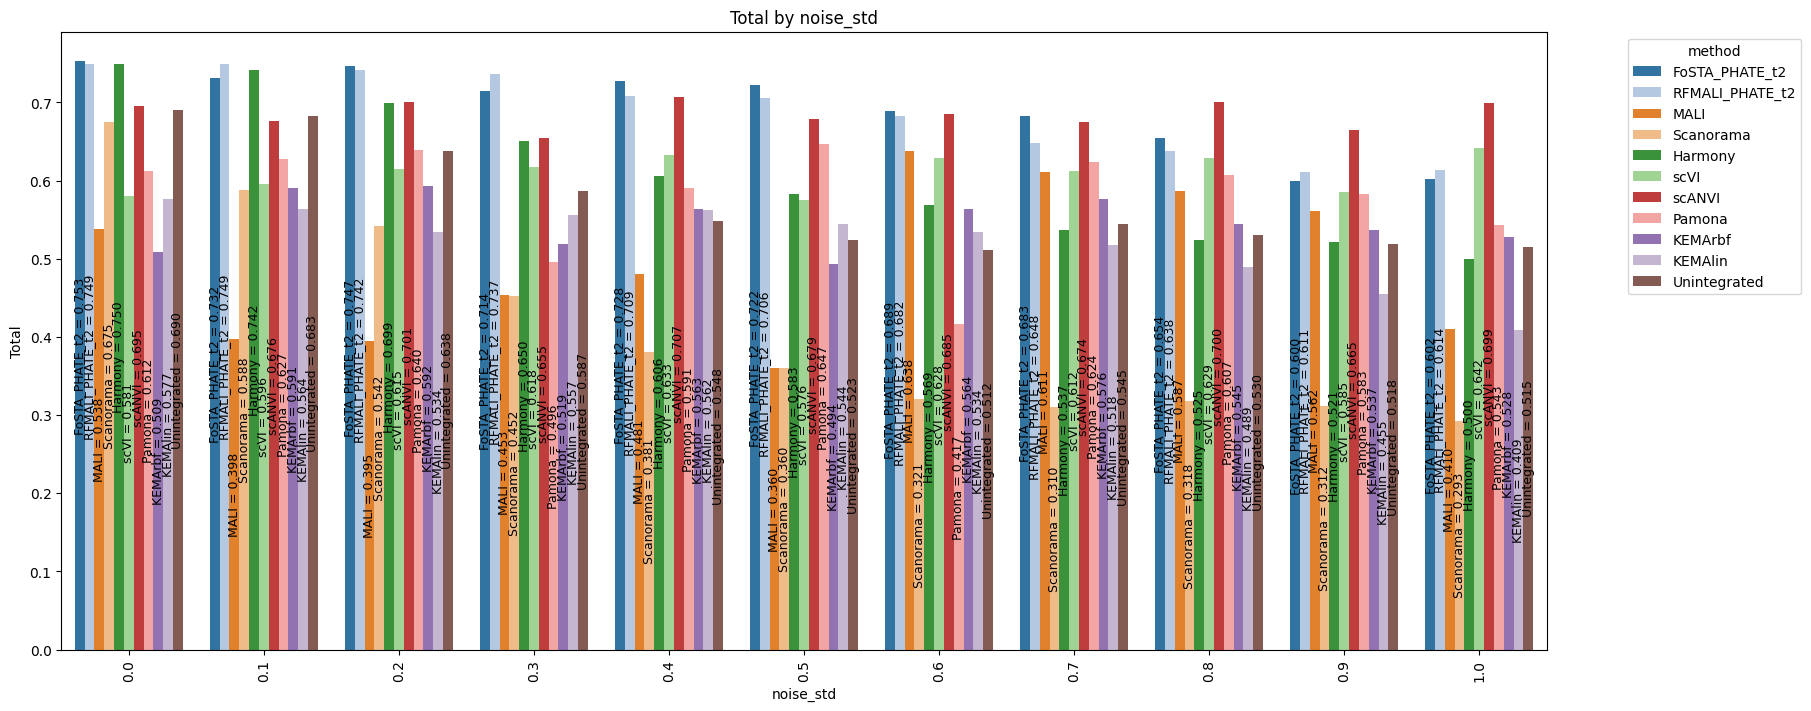

In [25]:
# pick one n_components and see effect of noise and dropout

n_comp = 2.0
dropout = 0.0

results_df_subset = results_df.loc[(results_df["n_components"] == n_comp) & (results_df["dropout_prob"] == dropout)]

plot_metric_grouped_by(results_df_subset, groupby_cols=["noise_std", "method"])


effect of dropout when fixing noise at 0

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


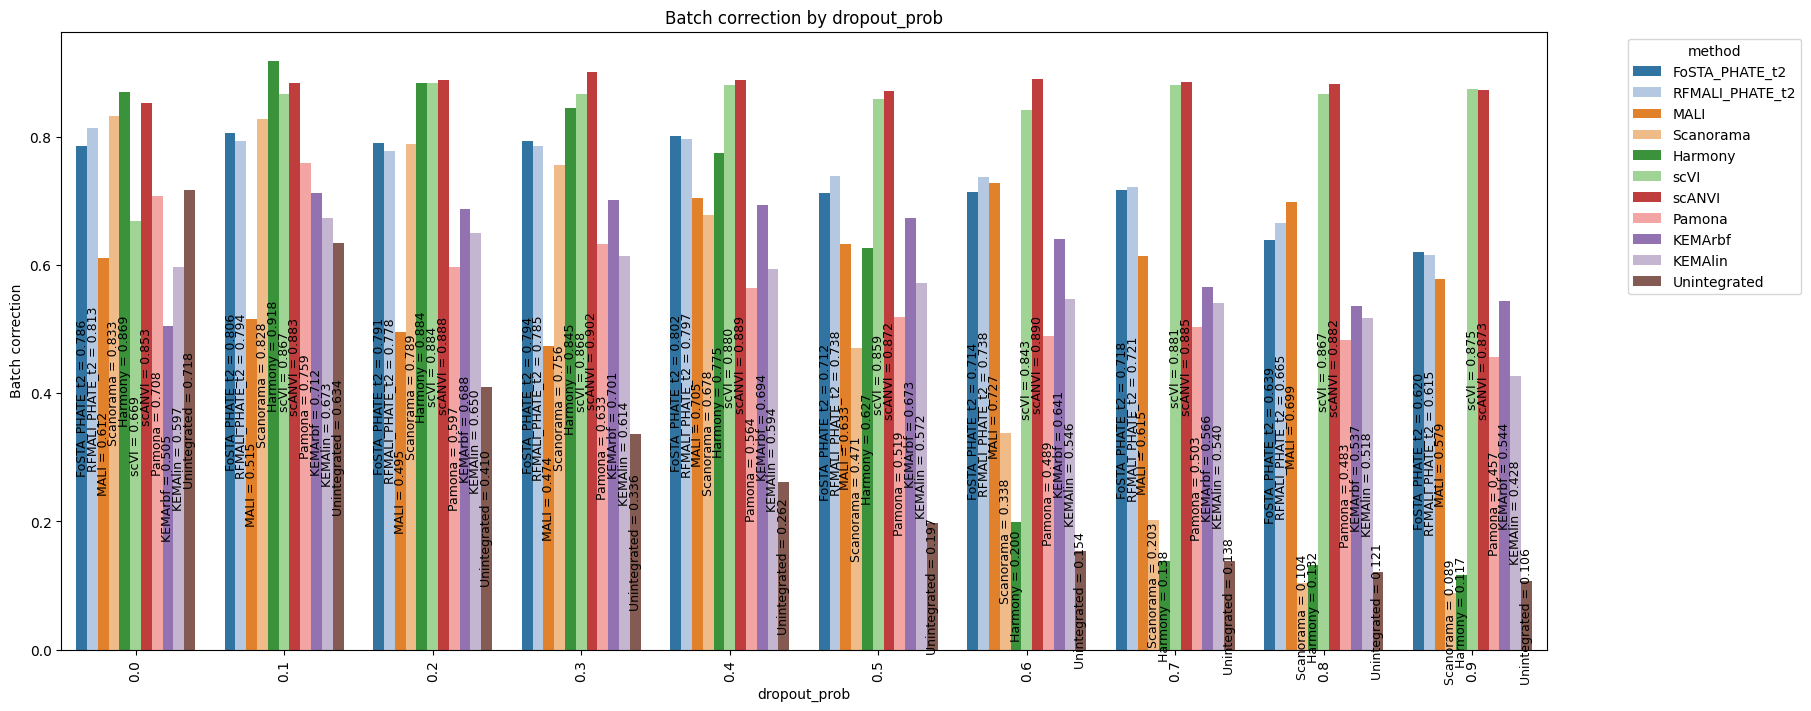

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


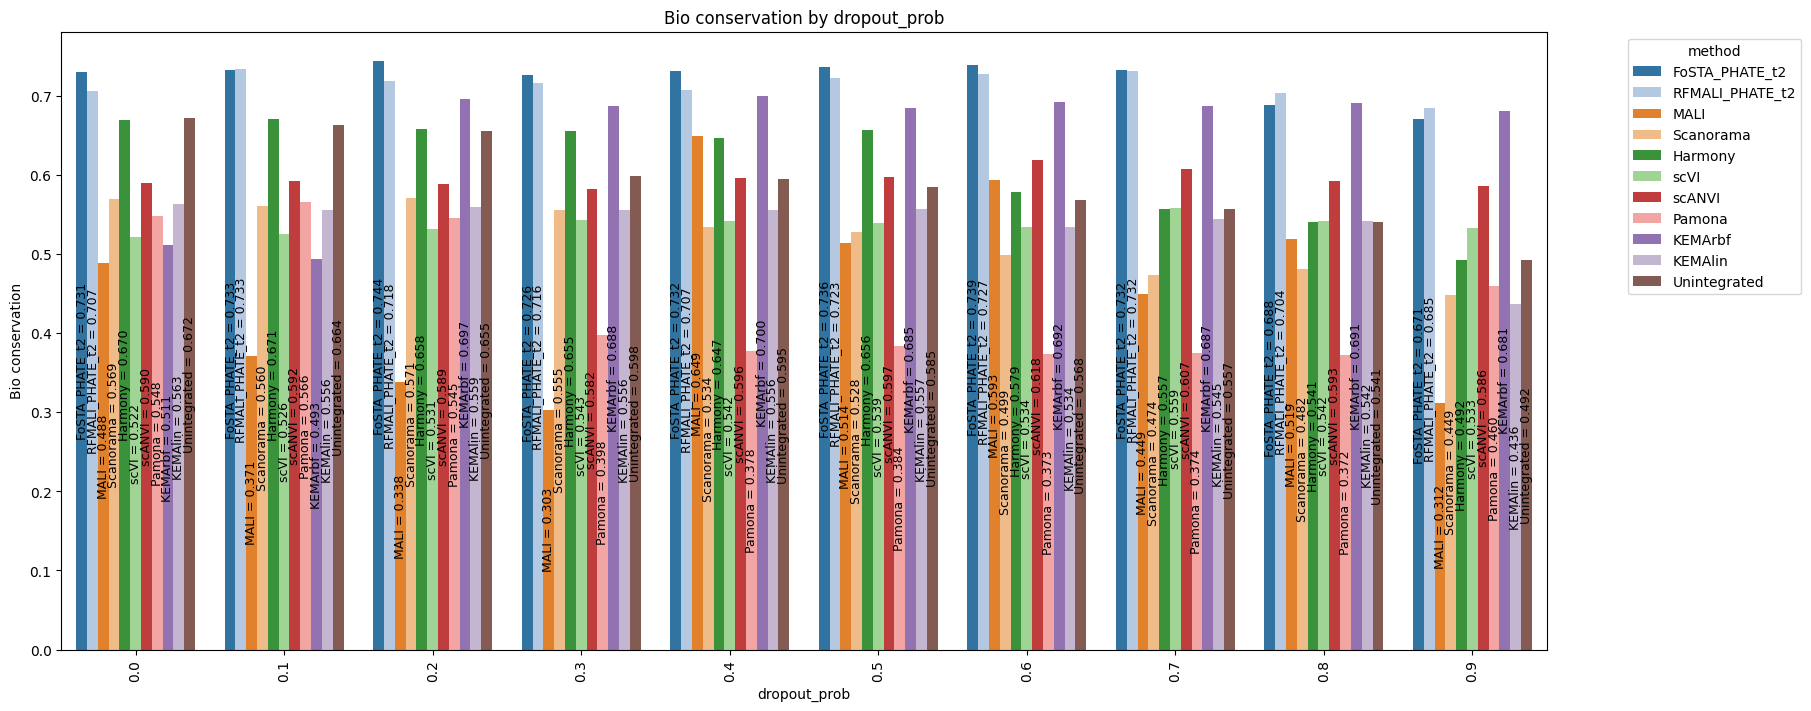

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


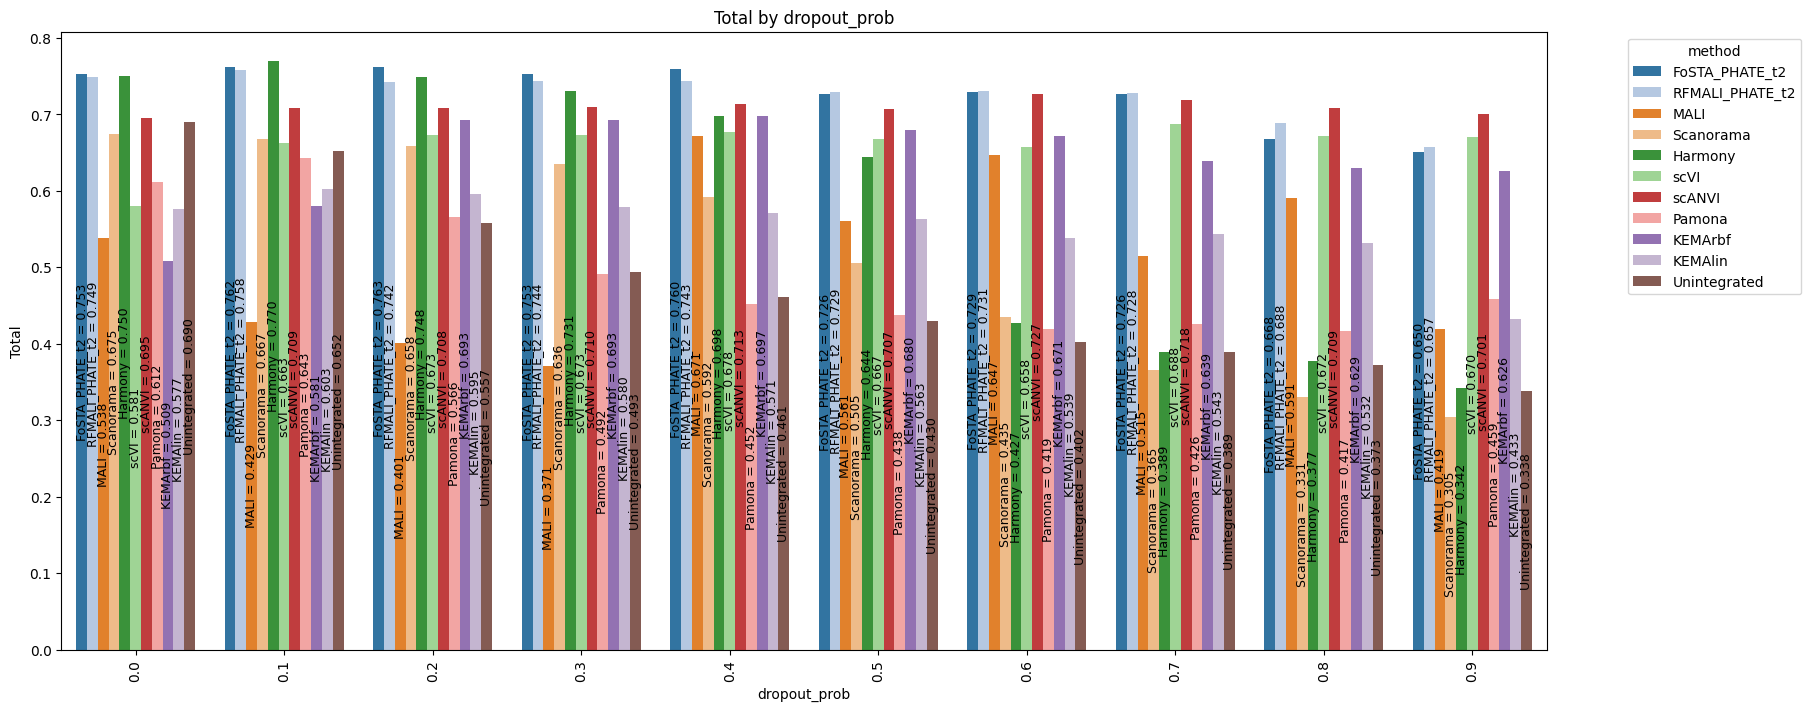

In [26]:
# pick one n_components and see effect of noise and dropout

n_comp = 2
noise = 0

results_df_subset = results_df.loc[(results_df["n_components"] == n_comp) & (results_df["noise_std"] == noise)]

plot_metric_grouped_by(results_df_subset, groupby_cols=["dropout_prob", "method"])

In [14]:
# # average over all components....
# cols_to_plot = ["Batch correction", "Bio conservation", "Total"]
# # 
# for col in cols_to_plot:
#    fig, ax = plt.subplots(figsize=(8, 6))
   
   
#    data = results_df.groupby(['n_components', 'method'])[col].mean()
#    print(data)
   
# #    data.plot(kind='bar', title=col)
#    for n_comp in results_df['n_components'].unique():
#       sns.barplot(data=data[n_comp])
   
   
#       # show the mean
#       for p in ax.patches:
#          h, w, x = p.get_height(), p.get_width(), p.get_x()
#          xy = (x + w / 2., h / 2)
#          text = f'{h:0.3f}'
#          ax.annotate(text=text, xy=xy, ha='center', va='top')
         
#       plt.title(f"{col} - n_components: {n_comp}")
#       plt.xticks(rotation=90)
#       plt.show()

for each method, heatmap of performance over different noise/dropout

In [85]:
# for method in results_df['method'].unique():
#     method_df = results_df[results_df['method'] == method]
#     # results_df["Total"] = pd.to_numeric(results_df["Total"], errors="coerce")
#     heatmap_df = method_df.pivot(index= "dropout_prob", columns= "noise_std", values = "Total")
    
#     # method_df = method_df.mean().to_frame(name='score')
    
#     plt.figure(figsize=(10,6))
#     sns.heatmap(data=heatmap_df, vmin=0, vmax=1, cmap= "viridis")
#     plt.title(f"Total Score for Method: {method}")
#     plt.ylabel("Dropout Probability")
#     plt.xlabel("Noise Standard Deviation")
    

# visualize embeddings

In [108]:
save_path

'/NOBACKUP/lizottem/fosta/results/simulated_batches/final_run/4'

/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:617: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({"cell_type": {"Type 2": "Alveolar Type 2"}}, inplace=True)
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:622: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({"cell_type": {"Endothelium": "Blood Endothelial Cell"}}, inplace=True)
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:624: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a fut

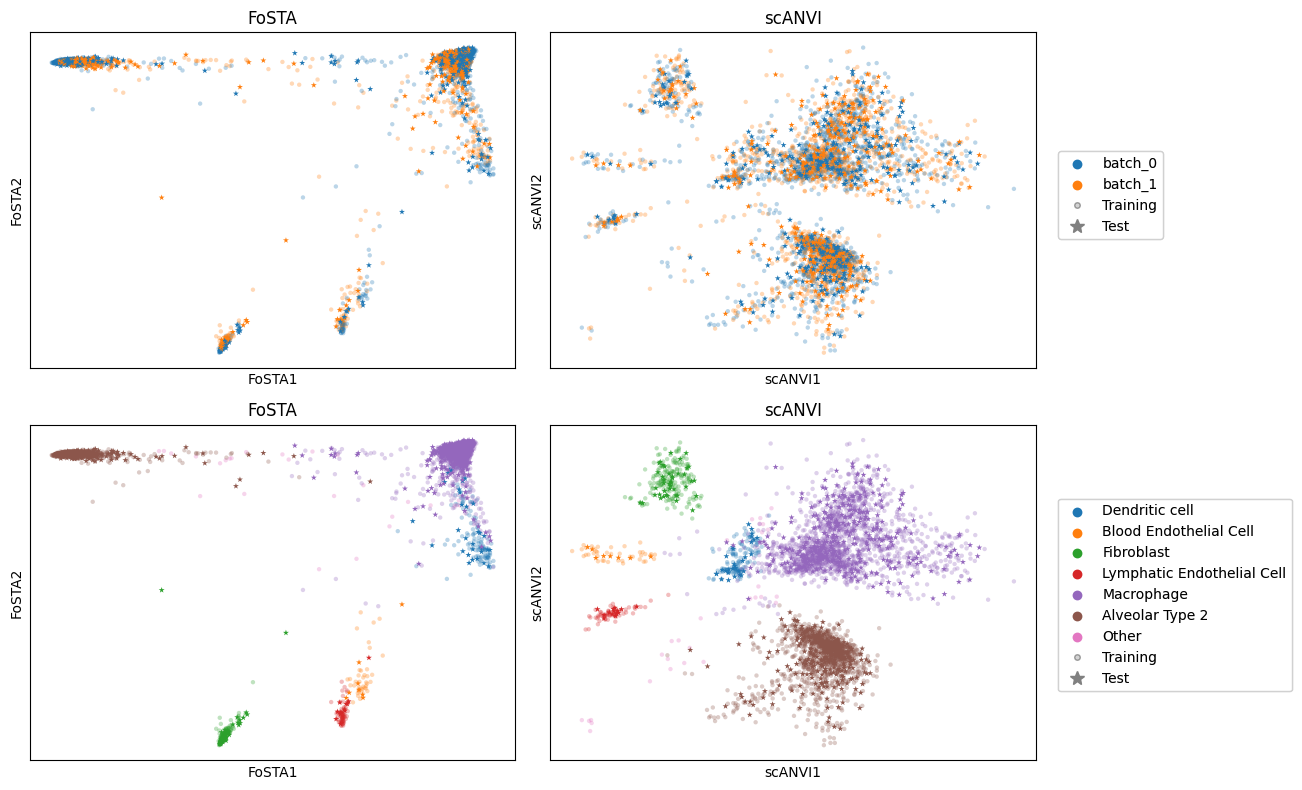

In [33]:
seed = 39041
right_fosta_key = "FoSTA_t2_balanced"
# right_fosta_key = "ICML FoSTA t=2"
adata = plot_embeddings(methods = ["FoSTA", "scANVI"], right_fosta_key = right_fosta_key, noise_level=0.5, dropout_level=0.5, seed=seed, save_path=save_path)


In [34]:
adata, path = add_rfphate_phate_embeddings(save_path = save_path, adata=None, noise_level=0.5, dropout_level=0.5, t=2)

Calculating PHATE...
  Running PHATE on 3763 observations and 30 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.09 seconds.
    Calculating affinities...


/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:617: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({"cell_type": {"Type 2": "Alveolar Type 2"}}, inplace=True)
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:622: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({"cell_type": {"Endothelium": "Blood Endothelial Cell"}}, inplace=True)
/home/lizottem/RF-MALI/notebooks/../utils/plotting_utils.py:624: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a fut

    Calculated affinities in 1.30 seconds.
  Calculated graph and diffusion operator in 1.40 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.31 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.81 seconds.
  Calculated landmark operator in 2.12 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.05 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 2.71 seconds.
Calculated PHATE in 6.78 seconds.
    SGD-MDS may not have converged: stress changed by 4.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


AnnData object with n_obs × n_vars = 3763 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'simulated_batch', 'cell_type_masked', 'mask_indices', 'cell_type_cleaned_encoded', '_scvi_batch', '_scvi_labels', 'original_cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'global_masking_fraction', 'hvg', 'memory_dict', 'pca', 'times_dict'
    obsm: 'FoSTA no pca', 'FoSTA_t2', 'FoSTA_t2_balanced', 'FoSTA_t2_et', 'FoSTA_tauto_gap', 'FoSTA_tauto_kerf', 'Harmony', 'ICML FoSTA t=2', 'ICML FoSTA t=auto', 'KEMAlin', 'KEMArbf', 'LIGER', 'MALI', 'New FoSTA gap t=2', 'New FoSTA gap t=auto', 'Pamona', 'Scanorama', 'Unintegrated', 'X', 'X_pca', 'scANVI', 'scVI', 'PHATE_t2', 'RFPHATE_t2', 'RFPHATE', 'PHATE', 'FoSTA'
    varm: 'PCs'
    laye

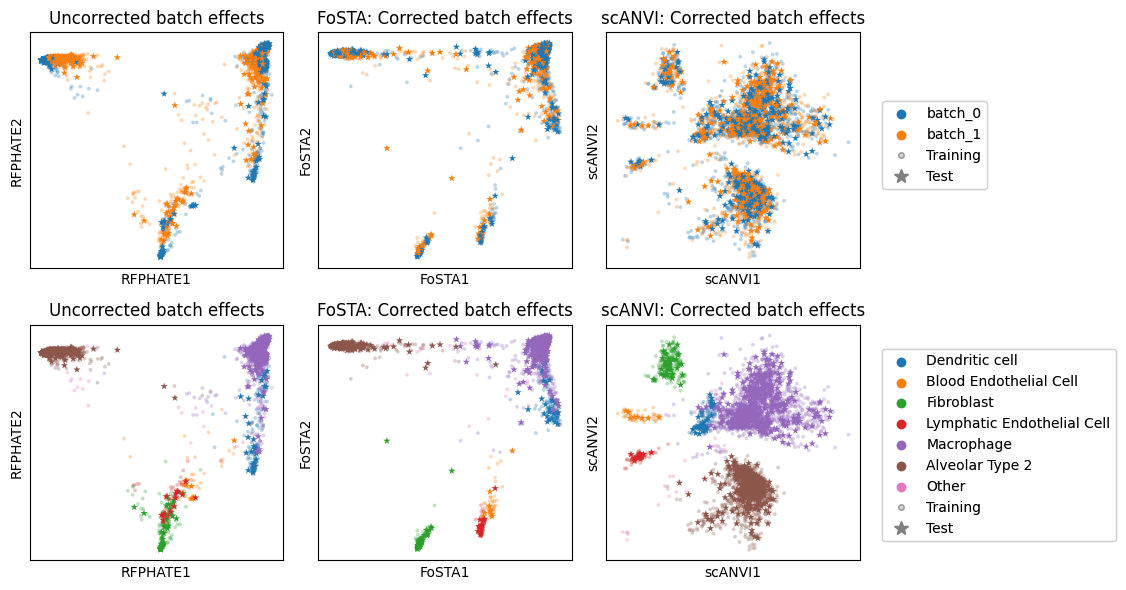

In [35]:
# rename RFPHATE_t2 to RFPHATE
adata.obsm["RFPHATE"] = adata.obsm["RFPHATE_t2"]
adata.obsm["PHATE"] = adata.obsm["PHATE_t2"]
# del adata.obsm["RFPHATE_t2"]


renames = {"PHATE_no_noise_t2": "PHATE: Before batch effects",
           "RFPHATE_no_noise_t2": "Before batch effects",
            "PHATE_t2": "Uncorrected batch effects",
            "RFPHATE" : "Uncorrected batch effects",
            "FoSTA": "FoSTA: Corrected batch effects",
            "scANVI": "scANVI: Corrected batch effects"}

# methods = ["PHATE_no_noise_t2", 
# methods = ["RFPHATE_no_noise_t2", 
        #    "PHATE_t2", 
methods = ["RFPHATE", 
           "FoSTA",
           "scANVI"]

plot_embeddings(adata, methods = methods, save_path = path,  right_fosta_key='FoSTA_t2_balanced', rename_dict=renames, figsize=(10,6), s=30)

/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


AnnData object with n_obs × n_vars = 3763 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'simulated_batch', 'cell_type_masked', 'mask_indices', 'cell_type_cleaned_encoded', '_scvi_batch', '_scvi_labels', 'original_cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'global_masking_fraction', 'hvg', 'memory_dict', 'pca', 'times_dict'
    obsm: 'FoSTA no pca', 'FoSTA_t2', 'FoSTA_t2_balanced', 'FoSTA_t2_et', 'FoSTA_tauto_gap', 'FoSTA_tauto_kerf', 'Harmony', 'ICML FoSTA t=2', 'ICML FoSTA t=auto', 'KEMAlin', 'KEMArbf', 'LIGER', 'MALI', 'New FoSTA gap t=2', 'New FoSTA gap t=auto', 'Pamona', 'Scanorama', 'Unintegrated', 'X', 'X_pca', 'scANVI', 'scVI', 'PHATE_t2', 'RFPHATE_t2', 'RFPHATE', 'PHATE', 'FoSTA'
    varm: 'PCs'
    laye

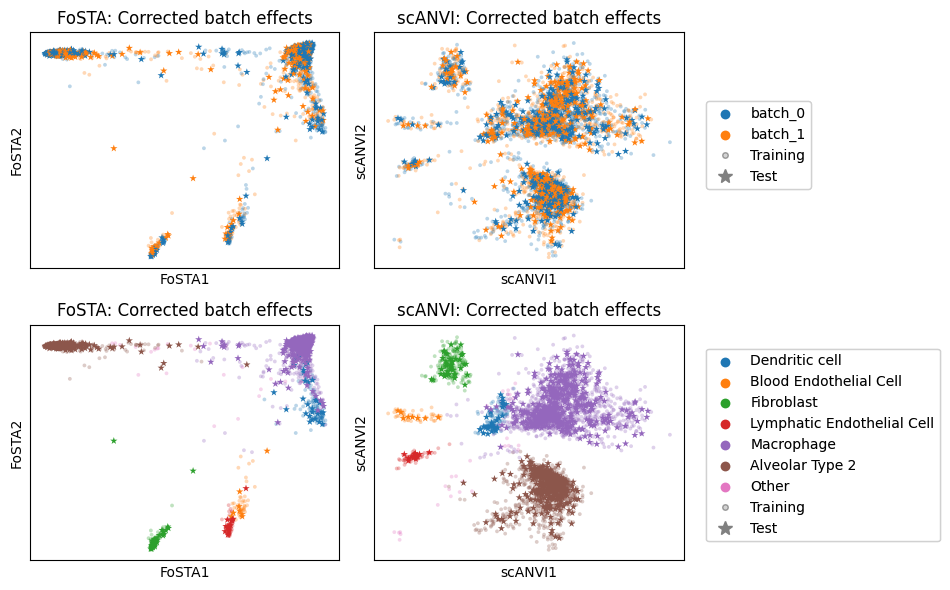

In [118]:
methods = ["FoSTA",
           "scANVI"]
plot_embeddings(adata, methods = methods, save_path = f"{path}/fig_noRFPHATE",  right_fosta_key='FoSTA_t2_balanced', rename_dict=renames, figsize=(8,6), s=30)

/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


AnnData object with n_obs × n_vars = 3763 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'simulated_batch', 'cell_type_masked', 'mask_indices', 'cell_type_cleaned_encoded', '_scvi_batch', '_scvi_labels', 'original_cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'global_masking_fraction', 'hvg', 'memory_dict', 'pca', 'times_dict'
    obsm: 'FoSTA no pca', 'FoSTA_t2', 'FoSTA_t2_balanced', 'FoSTA_t2_et', 'FoSTA_tauto_gap', 'FoSTA_tauto_kerf', 'Harmony', 'ICML FoSTA t=2', 'ICML FoSTA t=auto', 'KEMAlin', 'KEMArbf', 'LIGER', 'MALI', 'New FoSTA gap t=2', 'New FoSTA gap t=auto', 'Pamona', 'Scanorama', 'Unintegrated', 'X', 'X_pca', 'scANVI', 'scVI', 'PHATE_t2', 'RFPHATE_t2', 'RFPHATE', 'PHATE', 'FoSTA'
    varm: 'PCs'
    laye

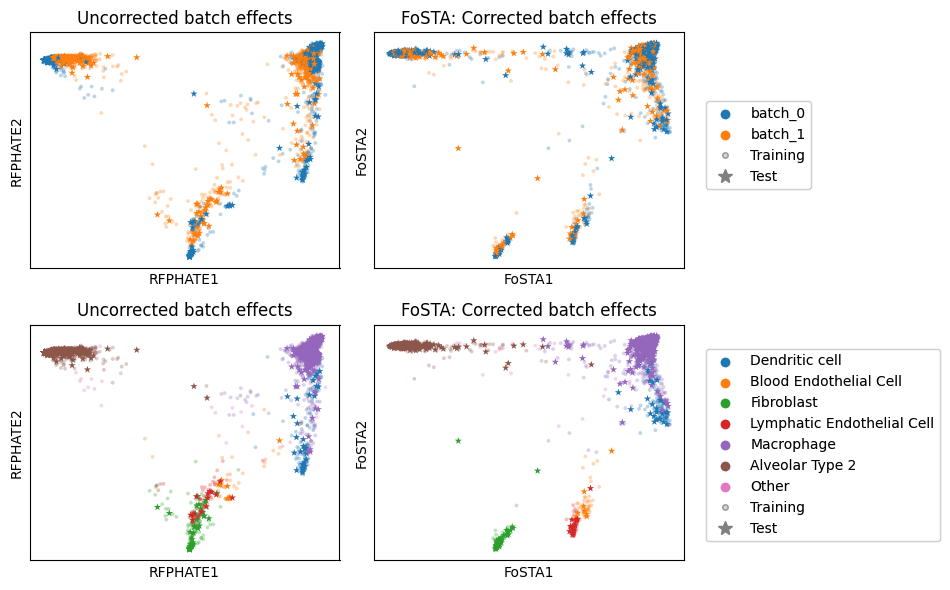

In [117]:
methods = ["RFPHATE", 
           "FoSTA"]


plot_embeddings(adata, methods = methods, save_path = f"{path}/fig_noscANVI",  right_fosta_key='FoSTA_t2_balanced', rename_dict=renames, figsize=(8,6), s=30)